In [186]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt


# import pandas as pd

# import scipy as sp
# from scipy.integrate import quad
# from scipy.stats import multivariate_normal

from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF

from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

from herculens.MassModel.mass_model_multiplane import MPMassModel
from herculens.LightModel.light_model_multiplane import MPLightModel
from herculens.LensImage.lens_image_multiplane import MPLensImage

In [187]:
PIXEL_SCALE = {'hubble': 0.04, 'euclid': 0.1, 'JWST': 0.063} # arcseconds
BACKGROUND_RMS = {'hubble': 8.7, 'euclid': 4.2, 'JWST': 15.8} # e- rms 
PSF_FILE = {# telescope : (filename, supersampling factor)
    'hubble': ('hubble_psf.npy', 4), 
    'euclid': ('euclid_psf.npy', 1),
    'JWST': ('JWST_psf.npy', 7)
}

In [188]:
def initialise_pixel_grid(fov: float, pixel_scale: float) -> PixelGrid:
        """
        initialise a square pixel grid instance

        Parameters
        ----------
        fov : float
            the field of view of the pixel grid in arcseconds
        pixel_scale : float
            the pixel width of the grid in arcseconds
        """

        nx = int(np.floor(fov/pixel_scale))
        ny = int(np.floor(fov/pixel_scale))

        # set central pixel to (0,0)
        half_size_x = (nx - 1) / 2
        half_size_y = (ny - 1) / 2
        ra_at_xy_0 = - half_size_x * pixel_scale
        dec_at_xy_0 = - half_size_y * pixel_scale

        transform_pix2angle = pixel_scale*np.eye(2)
        kwargs_pixel = {
            'nx': nx,
            'ny': ny,
            'ra_at_xy_0': ra_at_xy_0,
            'dec_at_xy_0': dec_at_xy_0,
            'transform_pix2angle': transform_pix2angle
        }

        return PixelGrid(**kwargs_pixel)
def initialise_models() -> tuple[MPMassModel, MPLightModel]:
    """initialise mass and light models of all planes in system"""
    lens_mass_model = MassModel(['EPL', 'SHEAR']) 
    lens_light_model = LightModel(['SERSIC_ELLIPSE'])

    source1_mass_model = MassModel(['SIS', 'SHEAR']) 
    source1_light_model = LightModel(['SERSIC_ELLIPSE'])  

    source2_light_model = LightModel(['SERSIC_ELLIPSE'])

    mp_mass_model = MPMassModel([
    lens_mass_model,          # deflector
    source1_mass_model       # source 1 mass model
    ])

    mp_light_model = MPLightModel([
        lens_light_model,     # lens galaxy light
        source1_light_model,  # first source light
        source2_light_model   # second source light
    ])

    return mp_mass_model, mp_light_model

def get_mass_light_parameters(extent: list) -> tuple[list,list]:
    # -- mass kwargs -- #
    q = np.random.uniform(0.4, 1.0)      
    phi = np.random.uniform(0, np.pi)   

    e = (1 - q) / (1 + q)
    e1 = e * np.cos(2 * phi)
    e2 = e * np.sin(2 * phi)

    lens_EPL_kwargs = {
        'theta_E': np.random.uniform(0.5, 1.0),
        'gamma': np.random.uniform(1.7, 2.3),
        'e1': e1,
        'e2': e2,
        'center_x': 0.0,
        'center_y': 0.0
    }
    lens_shear_kwargs = {
        'gamma1': np.random.uniform(0.0, 0.05),     
        'gamma2': np.random.uniform(0.0, 0.05),      
        'ra_0': lens_EPL_kwargs['center_x'],
        'dec_0': lens_EPL_kwargs['center_y'],
    }

    source1_SIS_kwargs = {
        'theta_E': np.random.uniform(0.1, lens_EPL_kwargs['theta_E']),     
        'center_x': np.random.normal(0.0, lens_EPL_kwargs['theta_E']),    
        'center_y': np.random.normal(0.0, lens_EPL_kwargs['theta_E'])    
    }
    source1_shear_kwargs = {
        'gamma1': np.random.uniform(0.0, 0.05),     
        'gamma2': np.random.uniform(0.0, 0.05),       
        'ra_0': source1_SIS_kwargs['center_x'],
        'dec_0': source1_SIS_kwargs['center_y'],
    }

    lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]
    source1_mass_kwargs = [source1_SIS_kwargs, source1_shear_kwargs]

    mp_mass_kwargs = [lens_mass_kwargs, source1_mass_kwargs]
    
    # -- light kwargs -- #
    lens_sersic_kwargs = {
        'amp': 1e4,         # TODO
        'R_sersic': 0.5,    # TODO
        'n_sersic': 4.0, # n=4: de Vaucouleurs profile
        'e1': lens_EPL_kwargs['e2'],
        'e2': lens_EPL_kwargs['e2'],
        'center_x': lens_EPL_kwargs['center_x'],
        'center_y': lens_EPL_kwargs['center_y']
    }
    lens_light_kwargs = [lens_sersic_kwargs]

    source1_sersic_kwargs = {
        'amp': 1e3,         # TODO  
        'R_sersic': 0.5,    # TODO
        'n_sersic': 4.0, # n=4: de Vaucouleurs profile
        'e1': 0.0,          # keep it spherical for now
        'e2': 0.0,          # keep it spherical for now
        'center_x': source1_SIS_kwargs['center_x'],
        'center_y': source1_SIS_kwargs['center_y']
    }
    source1_light_kwargs = [source1_sersic_kwargs]

    source2_sersic_kwargs = {
        'amp': 1e3,         # TODO
        'R_sersic': 0.5,    # TODO
        'n_sersic': 4.0, # n=4: de Vau couleurs profile
        'e1': 0.0,          # keep it spherical for now
        'e2': 0.0,          # keep it spherical for now
        'center_x': np.random.normal(0.0, lens_EPL_kwargs['theta_E']),    
        'center_y': np.random.normal(0.0, lens_EPL_kwargs['theta_E'])   
    }
    source2_light_kwargs = [source2_sersic_kwargs]

    mp_light_kwargs = [lens_light_kwargs, source1_light_kwargs, source2_light_kwargs]

    return mp_mass_kwargs, mp_light_kwargs

def get_noise_psf(nx: int, ny: int, pixel_width: float, 
                  *, telescope: str = 'euclid', exposure_time: float = 600.0):
    
    noise = Noise(nx, ny, background_rms=BACKGROUND_RMS[telescope], exposure_time=exposure_time)

    psf_filename, supersampling_factor = PSF_FILE[telescope]
    psf = PSF(
        psf_type='PIXEL',
        pixel_size=pixel_width,
        kernel_point_source=np.load(f"psf/{psf_filename}"),
        kernel_supersampling_factor=supersampling_factor
    )
    return noise, psf

def get_lens_image(
          fov: float = 5, 
          telescope: str = 'euclid', 
          exposure_time: float = 600.0
          ):
    pixel_grid = initialise_pixel_grid(fov, PIXEL_SCALE[telescope])
    nx, ny = pixel_grid.num_pixel_axes
    pixel_width = pixel_grid.pixel_width
    extent = pixel_grid.extent

    noise, psf = get_noise_psf(nx, ny, pixel_width, telescope=telescope, exposure_time=exposure_time)
    
    mp_mass_model, mp_light_model = initialise_models()

    mp_mass_kwargs, mp_light_kwargs = get_mass_light_parameters(extent)

    mp_lens_image = MPLensImage(
        grid_class=pixel_grid,
        psf_class=psf,
        noise_class=noise,
        mass_model_class=mp_mass_model,
        light_model_class=mp_light_model
    )

    return mp_lens_image, mp_mass_kwargs, mp_light_kwargs
    
def get_eta():
     return np.random.uniform(low=1.0, high=5.0)



In [189]:
mp_lens_image, mp_mass_kwargs, mp_light_kwargs = get_lens_image(fov=15)
eta = get_eta()


Model Parameters: 
    Lens
    ----
    (theta_E) = 0.9252619619963098
    (gamma) = 2.2255632394902287
    (e1,e2) = (np.float64(0.06872820017208998), np.float64(0.01665694907568276))
    (cx,cy) = (0.0, 0.0)
    (gamma1, gamma2) = (0.0006456616137750283, 0.01188113338347876)

    Source_1
    --------
    (theta_E) = 0.6142676896259727
    (cx,cy) = (-0.32821805486834926, -0.18318428794272953)
    (gamma1, gamma2) = (0.03166032912946793, 0.023054061736314024)

    Source_2
    --------
    (cx,cy) = (-1.109019510652179, 0.29733843597802445)



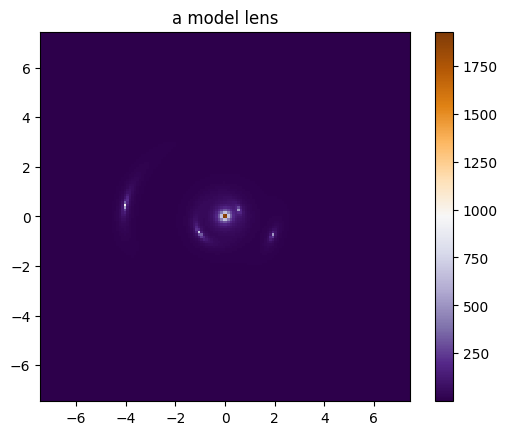

In [190]:
model_image = mp_lens_image.model(
    unconvolved=True, 
    kwargs_mass=mp_mass_kwargs, 
    kwargs_light=mp_light_kwargs, 
    eta_flat=jnp.array([eta])
    )

print(f"""
Model Parameters: 
    Lens
    ----
    (theta_E) = {mp_mass_kwargs[0][0]['theta_E']}
    (gamma) = {mp_mass_kwargs[0][0]['gamma']}
    (e1,e2) = {mp_mass_kwargs[0][0]['e1'], mp_mass_kwargs[0][0]['e2']}
    (cx,cy) = {mp_mass_kwargs[0][0]['center_x'], mp_mass_kwargs[0][0]['center_y']}
    (gamma1, gamma2) = {mp_mass_kwargs[0][1]['gamma1'], mp_mass_kwargs[0][1]['gamma2']}

    Source_1
    --------
    (theta_E) = {mp_mass_kwargs[1][0]['theta_E']}
    (cx,cy) = {mp_mass_kwargs[1][0]['center_x'], mp_mass_kwargs[1][0]['center_y']}
    (gamma1, gamma2) = {mp_mass_kwargs[1][1]['gamma1'], mp_mass_kwargs[1][1]['gamma2']}

    Source_2
    --------
    (cx,cy) = {mp_light_kwargs[2][0]['center_x'], mp_light_kwargs[2][0]['center_y']}
""")
# plt.imshow(model_image, origin='lower', cmap='PuOr_r', extent=mp_lens_image.Grid.extent, norm='log')
plt.imshow(model_image, origin='lower', cmap='PuOr_r', extent=mp_lens_image.Grid.extent)
plt.colorbar()
plt.title('a model lens')
# plt.savefig(f'figures_out/model_lens{i}.png')
plt.show()

Text(0.5, 1.0, 'a simulated lens')

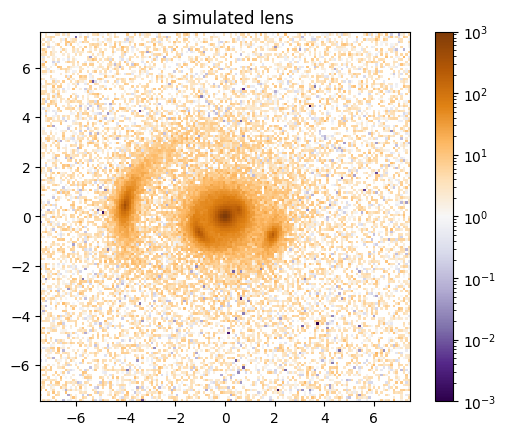

In [191]:
simulated_image = mp_lens_image.simulation(
    unconvolved=False, 
    kwargs_mass=mp_mass_kwargs, 
    kwargs_light=mp_light_kwargs, 
    eta_flat=jnp.array([eta])
    )

plt.imshow(simulated_image, origin='lower', cmap='PuOr_r', extent=mp_lens_image.Grid.extent, norm='log', vmin=1e-3, vmax=1e3)
# plt.imshow(simulated_image, origin='lower', cmap='inferno', extent=mp_lens_image.Grid.extent)
plt.colorbar()
plt.savefig("figures_out/noisy.png")
plt.title('a simulated lens')